# Practical session 2 - Practise with classic libraries

Students (pair):

 - [Antoine CORBY](https://github.com/antoinecorby)

 - [Astyan MARTIN](https://github.com/AstyanM)

**Useful references for this lab**:

[1] `numpy`: [lecture notes (1.4.1-1.4.2)](https://scipy-lectures.org/intro/numpy/index.html) and [documentation](https://numpy.org/doc/stable/)

[2] `pandas`: [documentation](https://pandas.pydata.org/docs/getting_started/index.html), [quick tutorial](https://pandas.pydata.org/pandas-docs/version/0.15/10min.html)

[3] `matplotlib`: [lecture notes (1.5)](https://scipy-lectures.org/intro/matplotlib/index.html) and [documentation](https://matplotlib.org/)

[4] `h5py`: [quick start guide](http://docs.h5py.org/en/stable/quick.html#quick)

## <a name="content">Contents</a>
- [Exercise 1: Computing basic statistics](#ex1)
- [Exercise 2: Random variables and histograms](#ex2)
- [Exercise 3: Discrete isotropic total variation](#ex3)
---

In [1]:
%load_ext autoreload
%autoreload 2

In [17]:
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import inspect

---
## <a name="ex1">Exercise 1: Random variables and histograms</a>

In this exercise, we are interested in generating samples from the Gamma distribution $\mathcal{G}(\alpha,\beta)$, of probability density function (pdf)

\begin{equation}
    p(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1} \exp(-\beta x) \mathbb{1}_{\mathbb{R}_+^*}(x),
\end{equation}

and displaying their histogram. In the following, we consider $(\alpha, \beta) = (9, 2)$.

1\. Set the random seed to a fixed value for reproducibility, and biefly check your instruction works as intended.
> Hint: you may take a look at the following pages: [random module](https://numpy.org/doc/stable/reference/random/index.html?highlight=random#module-numpy.random), [random generator](https://numpy.org/doc/stable/reference/random/generator.html).

**Answer**:

In [3]:
random.seed(8)
print(random.random())

random.seed(8)
print(random.random()) 

0.2267058593810488
0.2267058593810488


2\. Generate $\approx 10^5$ samples in a vector. Save the vector in a file, `samples.hdf5` or `samples.npy`.
> Warning / hint: 
> - take a careful look at the [documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.gamma.html?highlight=gamma#numpy.random.gamma) (multiple conventions exist for the definition of the pdf underlying the distribution...);
> - to save data in a `npy` file, take a look at the example reported in the [Numpy documentation](https://numpy.org/doc/stable/reference/generated/numpy.save.html);
> - to save data in a `.h5` file, take a quick look at the [documentation here](https://docs.h5py.org/en/stable/quick.html#quick).

**Answer**:

In [4]:
alpha = 9
beta = 2
samples = np.random.gamma(shape=alpha, scale=1/beta, size=10**5)
np.save('samples.npy', samples)

3\. Estimate an histogram of this distribution for a well chosen set of bins, and display it.
> Warnings: 
> - make sure the [histogram](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html?highlight=hist#matplotlib.pyplot.hist) corresponds to a probability density function (pdf);
> - do not forget to include a proper title with names for the axes.

**Answer**:

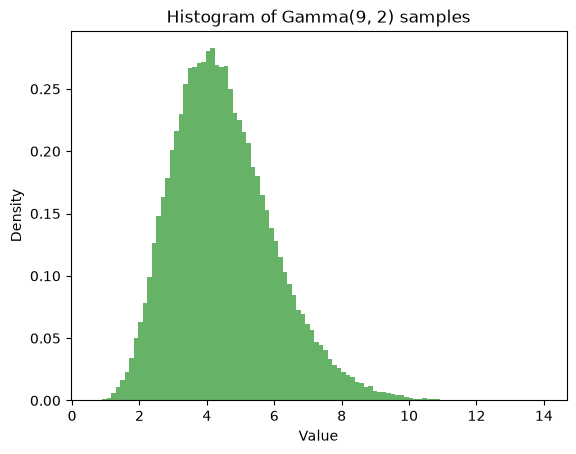

In [5]:
counts, bins, _ = plt.hist(samples, bins=100, density=True, alpha=0.6, color='g')
plt.title('Histogram of Gamma(9, 2) samples')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

4\. Overlay the probability density function on the histogram and compare these in a few words. Save the resulting picture in `.png` format.
> Hint: 
> - take a look at the `scipy` [documentation](https://docs.scipy.org/doc/scipy/reference/stats.html) to avoid implementing the pdf from scratch;
> - return the bins in which the histogram is computed, and evaluate the pdf on those points.

**Answer**:

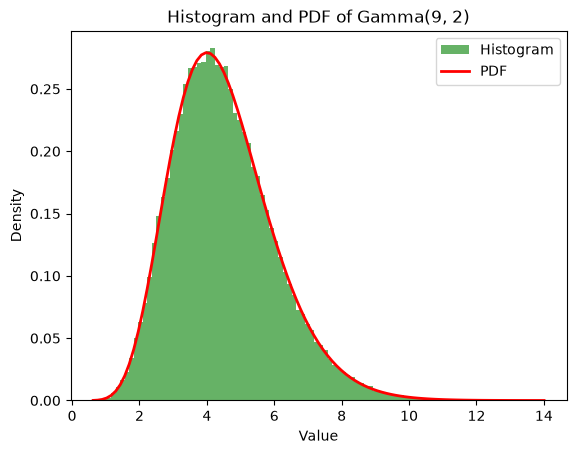

Comparison: The empirical histogram closely matches the theoretical probability density function, as expected for a large number of samples.


In [6]:
from scipy.stats import gamma

counts, bins, _ = plt.hist(samples, bins=100, density=True, alpha=0.6, color='g', label='Histogram')
pdf_values = gamma.pdf(bins, a=alpha, scale=1/beta)
plt.plot(bins, pdf_values, 'r-', lw=2, label='PDF')

plt.title('Histogram and PDF of Gamma(9, 2)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('gamma_hist_pdf.png')
plt.show()

print("Comparison: The empirical histogram closely matches the theoretical probability density function, as expected for a large number of samples.")


---
## <a name="ex2">Exercise 2: Basic statistics with `pandas`</a>

In this second exercise, we focus on computing basic statistics, and applying linear regression to a small data set. These data are gathered in the following table, which gives the infant mortality (`X`) and the gross national product per inhabitant (`Y`) of 12 european countries :

| `X` | 190 | 128 | 180 | 212 | 56 | 192 | 68 | 98 | 110 | 197 | 181 | 233 |
|-----|-----|-----|-----|----|-----|----|----|-----|-----|-----|-----|-----|
| `Y` |  24 |  28 |  24 | 19 |  37 | 22 | 34 |  25 |  36 |  24 |  20 |  18 |

1\. For `X `and `Y`, compute the median, mean, variance and standard deviation. The data points have already been entered into a `.csv` file stored in `data/data.csv`.
> Hint: 
> - you can directly use `pandas` to load the data into a `DataFrame` ([`pd.read_csv`](https://pandas.pydata.org/docs/reference/frame.html));
> - take a look at the built-in operations available for `DataFrame` objects ([documentation](https://pandas.pydata.org/docs/reference/frame.html));
> - to display a `DataFrame` `f`:
> ```python 
> from IPython.display import display
> display(df)
> ```
> - sort the `DataFrame` with respect to the value of `X` (see [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html#pandas.DataFrame.sort_values)) This will be useful for question 3.

**Answer**:

In [7]:
from IPython.display import display

# Load data
df = pd.read_csv('data/data.csv')

# Compute statistics
stats = df.agg(['median', 'mean', 'var', 'std'])
print("Statistics for X and Y:")
display(stats)

# Sort DataFrame with respect to X
df = df.sort_values(by='X').reset_index(drop=True)
print("\nSorted DataFrame:")
display(df)

Statistics for X and Y:


,X,Y
median,180.500000,24.000000
mean,153.750000,25.916667
var,3486.022727,42.446970
std,59.042550,6.515134



Sorted DataFrame:


,X,Y
0,56,37
1,68,34
2,98,25
3,110,36
4,128,28
5,180,24
6,181,20
7,190,24
8,192,22
9,197,24


2\. Give the equation of the regression line of `Y` as a function of `X`.
> Hint: 
> - take a look at the functionalities available in `numpy` (e.g., `np.polyfit` and `np.polyval`);
> - if needed, note that you can retrieve the data from the resulting `pandas` `DataFrame` with the `to_numpy()` method.

**Answer**:

In [8]:
x = df['X'].to_numpy()
y = df['Y'].to_numpy()
coeffs = np.polyfit(x, y, 1)
print(f"Regression line: Y = {coeffs[0]:.4f} * X + {coeffs[1]:.4f}")

Regression line: Y = -0.0982 * X + 41.0095


3\. Display the cloud of points and the regression line $Y = f(X)$ on the same figure. Save the figure in `.png` format.

**Answer**:

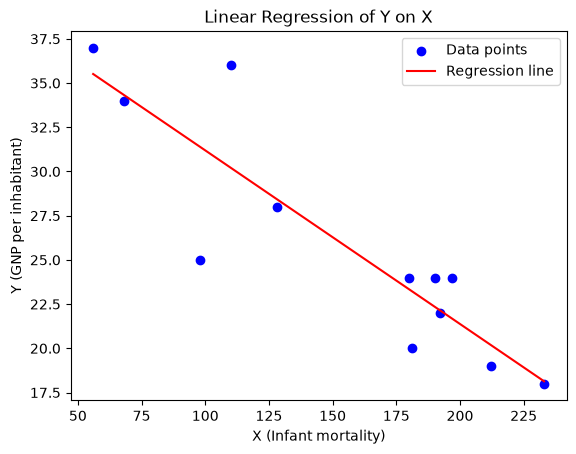

In [9]:
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, np.polyval(coeffs, x), color='red', label='Regression line')
plt.xlabel('X (Infant mortality)')
plt.ylabel('Y (GNP per inhabitant)')
plt.title('Linear Regression of Y on X')
plt.legend()
plt.savefig('regression.png')
plt.show()

---
## <a name="ex3">Exercise 3: Discrete isotropic total variation</a>

This exercise is devoted to the computation of the discrete isotropic total variation (TV) of an input matrix $\mathbf{X} = [\mathbf{x}_n]_{1 \leq n \leq N} \in\mathbb{C}^{M \times N}$, which is particularly useful in Bayesian inference (e.g., for inverse problems) to promote piece-wise smooth solutions. The TV is defined as

\begin{equation*}
    \text{TV}(\mathbf{X}) = \Vert D(\mathbf{X}) \Vert_{1,2} = \sum_{m=1}^M \sum_{n=1}^N \sqrt{[\mathbf{XD}_h]^2_{m,n} + [\mathbf{D}_v\mathbf{X}]^2_{m,n}},
\end{equation*}

where $[\mathbf{Z}]_{m,n}$ denotes the elements in position $(m,n)$ of the matrix $\mathbf{Z}$,

\begin{align*}
    D(X) &= (\mathbf{XD}_h, \mathbf{D}_v\mathbf{X}) \in \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \\
    %
    \mathbf{XD}_h &= [\mathbf{x}_2-\mathbf{x}_1, \dotsc, \mathbf{x}_N-\mathbf{x}_{N-1}, \mathbf{0}_M] \in \mathbb{C}^{M\times N} \\
    %
    \mathbf{D}_v\mathbf{X} &= [\tilde{\mathbf{x}}_2^T-\tilde{\mathbf{x}}^T_1, \dotsc, \tilde{\mathbf{x}}^T_M-\tilde{\mathbf{x}}^T_{M-1}, \mathbf{0}_N]^T \in \mathbb{C}^{M\times N},
\end{align*}

$\mathbf{x}_n \in \mathbb{C}^{M}$ is the $n$-th column of $\mathbf{X}$, and $\tilde{\mathbf{x}}_m \in \mathbb{C}^{1\times N}$ is the $m$-th row of $\mathbf{X}$. 
The linear operator $D: \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} $ is the discrete gradient operator. The adjoint of $D$, $D^*: \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N}$, is given by

\begin{align*}
    (\forall \mathbf{Y} = (\mathbf{Y}_h,\mathbf{Y}_v)), \quad D^*(\mathbf{Y}) &= \mathbf{Y}_h\mathbf{D}^*_h + \mathbf{D}^*_v\mathbf{Y}_v \\
    %
    \mathbf{Y}_h\mathbf{D}^*_h &= \big[-\mathbf{y}_{h,1},- [\mathbf{y}_{h,n}-\mathbf{y}_{h,n-1}]_{2 \leq n \leq N-1}, \mathbf{y}_{h, N-1} \big] \\
    %
    \mathbf{D}^*_v\mathbf{Y}_v &= \big[-\tilde{\mathbf{y}}_{v,1}^T,- [\tilde{\mathbf{y}}_{v,m}^T-\tilde{\mathbf{y}}^T_{v,m-1}]_{2 \leq m \leq M-1}, \tilde{\mathbf{y}}^T_{v, M-1} \big]^T
\end{align*}

where $\mathbf{y}_{h,n}$ is the $n$-th column of $\mathbf{Y}_h$, and $\tilde{\mathbf{x}}_{v,m}$ is the $m$-th row of $\mathbf{Y}_v$.

1\. Using `numpy`, implement a function `gradient2D` to compute the 2D discrete gradient operator $D$ applied to a matrix $\mathbf{X}\in\mathbb{C}^{M \times N}$ (no for loops!). Trigger an error message whenever the input array has more than 2 dimensions. If not clear from the implementation, add a few short comments to explain your code.

> Hint: 
> - to trigger an error, you can for instance use an `assert` statement, or raise an [exception (e.g., `AssertionError`)](https://docs.python.org/3/library/exceptions.html);
> - only a few operations are needed: computing vertical differences, horizontal differences, and possibly a concatenation of matrices into a single tensor (= n-dimensional array);
> - possibly useful functions: `np.diff`, `np.c_`, `np.r_` (or `np.concatenate`). 

**Answer**:

In [18]:
from src.gradient import gradient2D

print(inspect.getsource(gradient2D))

def gradient2D(X):
    """
    Computes the 2D discrete gradient operator D applied to a matrix X.
    
    Parameters:
    X : array_like, 2D
        Input matrix of shape (M, N).
        
    Returns:
    D : ndarray
        Output tensor of shape (2, M, N), where D[0] is X*D_h and D[1] is D_v*X.
    """
    assert X.ndim == 2, "Input array must have exactly 2 dimensions"
    
    # Horizontal differences: append a column of zeros
    X_dh = np.c_[np.diff(X, axis=1), np.zeros(X.shape[0])]
    
    # Vertical differences: append a row of zeros
    D_vx = np.r_[np.diff(X, axis=0), np.zeros((1, X.shape[1]))]
    
    # Combine into a single tensor of shape (2, M, N)
    return np.array([X_dh, D_vx])



2\. Implement a unit-test to validate the behaviour of the `gradient2D` function. For instance, you can check the format of the output, and test the result when the function is evaluated on a constant matrix (for both a square and a non-square input matrix). Run the unit-test from the present Jupyter notebook.

**Answer**:

In [12]:
import pytest
if __name__ == '__main__':
    pytest.main(['-v', '-s', 'tests/test_gradient.py::test_gradient2D'])

============================= test session starts =============================
platform win32 -- Python 3.13.2, pytest-9.1.1, pluggy-1.6.0 -- c:\Users\marti\Documents\Centrale\Python\env\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\marti\Documents\Centrale\Python\python_sdia_local\Labs\Lab2
plugins: anyio-4.15.1
collecting ... collected 1 item

tests/test_gradient.py::test_gradient2D 
test_gradient2D passed!
PASSED

============================== 1 passed in 0.07s ==============================


3\. Document the function `gradient2D` with an appropriate docstring (see Lab 1).

**Answer**:

In [13]:
help(gradient2D)

Help on function gradient2D in module src.gradient:

gradient2D(X)
    Computes the 2D discrete gradient operator D applied to a matrix X.

    Parameters:
    X : array_like, 2D
        Input matrix of shape (M, N).

    Returns:
    D : ndarray
        Output tensor of shape (2, M, N), where D[0] is X*D_h and D[1] is D_v*X.



4\. Using 1., define a function `tv` to compute $\text{TV}(\mathbf{X})$, $\mathbf{X}\in\mathbb{C}^{M \times N}$. Write a unit-test and document your function.

**Answer**:

In [ ]:
from src.gradient import tv

print(inspect.getsource(tv))

if __name__ == '__main__':
    pytest.main(['-v', '-s', 'tests/test_gradient.py::test_tv'])

help(tv)

def tv(X):
    """
    Computes the discrete isotropic total variation of a matrix X.
    
    Parameters:
    X : array_like, 2D
        Input matrix of shape (M, N).
        
    Returns:
    tv_val : float
        Total variation of X.
    """
    D = gradient2D(X)
    return np.sum(np.sqrt(np.abs(D[0])**2 + np.abs(D[1])**2))

============================= test session starts =============================
platform win32 -- Python 3.13.2, pytest-9.1.1, pluggy-1.6.0 -- c:\Users\marti\Documents\Centrale\Python\env\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\marti\Documents\Centrale\Python\python_sdia_local\Labs\Lab2
plugins: anyio-4.15.1
collecting ... collected 1 item

tests/test_gradient.py::test_tv 
test_tv passed
PASSED

============================== 1 passed in 0.02s ==============================
Help on function tv in module src.gradient:

tv(X)
    Computes the discrete isotropic total variation of a matrix X.

    Parameters:
    X : array_like, 2D
        In

5\. Implement a function `gradient2D_adjoint` to compute $D^*(\mathbf{Y})$, the adjoint of the 2D discrete gradient operator $D$ applied to $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$. Add a few short comments to explain your code whenever appropriate.

**Answer**:

In [20]:
from src.gradient import gradient2D_adjoint

print(inspect.getsource(gradient2D_adjoint))

def gradient2D_adjoint(Y):
    """
    Computes the adjoint of the 2D discrete gradient operator applied to Y.
    Y : array_like, shape (2, M, N)
    """
    Y_h, Y_v = Y[0], Y[1]
    M, N = Y_h.shape
    
    # Horizontal part (adjoint of diff + pad)
    if N > 1:
        diff_h = Y_h[:, 1:N-1] - Y_h[:, 0:N-2]
        Yh_Dh = np.c_[-Y_h[:, 0], -diff_h, Y_h[:, N-2]]
    else:
        Yh_Dh = np.zeros_like(Y_h)
        
    # Vertical part (adjoint of diff + pad)
    if M > 1:
        diff_v = Y_v[1:M-1, :] - Y_v[0:M-2, :]
        Dv_Yv = np.r_[[-Y_v[0, :]], -diff_v, [Y_v[M-2, :]]]
    else:
        Dv_Yv = np.zeros_like(Y_v)
        
    return Yh_Dh + Dv_Yv



6\. Implement a unit-test to validate `gradient2D_adjoint`, e.g., by checking the size of the output from the function and verifying that `gradient2D_adjoint` is adjoint to `gradient2D`, i.e., for any $\mathbf{X}\in\mathbb{C}^{M \times N}$ and $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$:

\begin{equation}
    \forall \mathbf{X} \in \mathbb{C}^{M \times N}, \mathbf{Y} = (\mathbf{Y}_h, \mathbf{Y}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \;
    %
    \langle D(\mathbf{X}), \mathbf{Y} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{X}, D^*(\mathbf{Y}) \rangle_{\mathbb{C}^{M \times N}}, 
\end{equation}

where 

\begin{align}
    &\forall \mathbf{U}, \mathbf{V} \in \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N}} = \text{Tr}(\mathbf{U}^T \mathbf{V}) = \sum_{m=1}^M \sum_{n=1}^N u_{m,n}^* v_{m,n}, \\
    &\forall \mathbf{U} = (\mathbf{U}_h, \mathbf{U}_v), \mathbf{V} = (\mathbf{V}_h, \mathbf{V}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{U}_h, \mathbf{V}_h \rangle_{\mathbb{C}^{M \times N}} + \langle \mathbf{U}_v, \mathbf{V}_v \rangle_{\mathbb{C}^{M \times N}}.
\end{align}

> Hint: to verify `gradient2D_adjoint` is the adjoint of `gradient2D`, evaluate the scalar products above for randomly drawn matrices. Set the random generator to a known state for reproducibility (see [Exercise 1](#ex1)).

> `np.conj` is useful.

**Answer**:

In [21]:
if __name__ == '__main__':
    pytest.main(['-v', '-s', 'tests/test_gradient.py::test_adjoint'])

============================= test session starts =============================
platform win32 -- Python 3.13.2, pytest-9.1.1, pluggy-1.6.0 -- c:\Users\marti\Documents\Centrale\Python\env\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\marti\Documents\Centrale\Python\python_sdia_local\Labs\Lab2
plugins: anyio-4.15.1
collecting ... collected 1 item

tests/test_gradient.py::test_adjoint 
test_adjoint passed
PASSED

============================== 1 passed in 0.02s ==============================


[Bonus, **optional**]. Generalize the `gradient2D` to any number of dimensions ($\mathbf{X} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}$), i.e., by returning tensors obtained by computing differences along each of its dimensions.
> Hint: 
> - you may use a loops here, and/or list comprehension. Using slice objects (see [np.s_](https://numpy.org/doc/stable/reference/generated/numpy.s_.html?highlight=s_#numpy.s_) and [this page](https://stackoverflow.com/questions/24432209/python-index-an-array-using-the-colon-operator-in-an-arbitrary-dimension)) can be an interesting option.
>
> - the definition of the scalar product above can be extended to the case of tensors as follows:
\begin{equation}
    \mathbf{U}, \mathbf{V} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}} =  \sum_{n_1 = 1}^{N_1}  \sum_{n_2 = 1}^{N_2} \dotsc \sum_{n_p = 1}^{N_p} u_{n_1, n_2, \dotsc, n_p}^* v_{n_1, n_2, \dotsc, n_p}   
\end{equation}

**Answer**:

In [22]:
from src.gradient import gradientND

# Quick test
X_nd = np.random.randn(3, 4, 5)
D_nd = gradientND(X_nd)
print(f"Shape of X_nd: {X_nd.shape}")
print(f"Shape of D_nd: {D_nd.shape}")

Shape of X_nd: (3, 4, 5)
Shape of D_nd: (3, 3, 4, 5)


## Reference

```bibtex
@article{condat:hal-01309685,
  TITLE = {{Discrete Total Variation: New Definition and Minimization}},
  AUTHOR = {Condat, Laurent},
  URL = {https://hal.archives-ouvertes.fr/hal-01309685},
  JOURNAL = {{SIAM Journal on Imaging Sciences}},
  PUBLISHER = {{Society for Industrial and Applied Mathematics}},
  VOLUME = {10},
  NUMBER = {3},
  PAGES = {1258--1290},
  YEAR = {2017},
  MONTH = Aug,
  DOI = {10.1137/16M1075247},
  KEYWORDS = { variational image processing ; total variation ;  finite-difference schemes ;  coarea formula},
  PDF = {https://hal.archives-ouvertes.fr/hal-01309685v3/file/Condat-newTV.pdf},
  HAL_ID = {hal-01309685},
  HAL_VERSION = {v3},
}
```
